# RETINEXPLAIN -- Baseline models (Logistic Regression, Decision Tree, Random forest)
**Author:** Ashik Kannampilly Janardhanan | MSc Artificial Intelligence and Machine Learning
**Student ID:** 25032615 | University of Limerick
**Supervisors:** Dr. Allan de Lima and Dr. Douglas Mota Dias


### Cell 1 -- Package Installation

#### Installs the scikit-fuzzy package required for fuzzy logic operations.

In [1]:
!pip install scikit-fuzzy -q
print("Dependencies ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.1 MB/s eta 0:00:0000:010:01
Dependencies ready.


## Cell 2 -- Libraries


#### Imports all required libraries and sets global configuration constants including dataset paths, device selection and disease/concept name lists used throughout the notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import warnings
from scipy import stats
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    precision_score, recall_score
)
SEED = 123
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)
random.seed(SEED)
DATASET_PATH  = '/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k'
IMAGES_PATH   = os.path.join(DATASET_PATH, 'preprocessed_images')
OUTPUT_PATH   = '/kaggle/working'
device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
disease_names = ['Normal', 'Diabetic Retinopathy', 'Glaucoma',
                 'Cataract', 'AMD', 'Hypertension', 'Myopia']
concepts_list    = ['haemorrhage', 'drusen', 'disc_pallor',
                    'vessel_tortuosity', 'red_spot', 'exudate']
concepts_display = ['Haemorrhage', 'Drusen', 'Disc Pallor',
                    'Vessel Tortuosity', 'Red Spot', 'Exudate']

print("Libraries ready.")

Libraries ready.


## Cell 3 -- Load and Clean Dataset

#### Loads the ODIR-5K CSV, filters to single-label images only using the per-image labels column, and maps disease codes to human-readable names. Multi-label and Other category rows are excluded, leaving 5,684 usable images across 7 disease classes.

In [3]:
df = pd.read_csv(os.path.join(DATASET_PATH, 'full_df.csv'))

label_map    = {'N': 'Normal', 'D': 'Diabetic Retinopathy', 'G': 'Glaucoma',
                'C': 'Cataract', 'A': 'AMD', 'H': 'Hypertension', 'M': 'Myopia'}
label_to_idx = {'N': 0, 'D': 1, 'G': 2, 'C': 3, 'A': 4, 'H': 5, 'M': 6}

def parse_label(label_str):
    return str(label_str).replace('[', '').replace(']', '').replace("'", '').strip()

df['label_parsed'] = df['labels'].apply(parse_label)
df_clean = df[df['label_parsed'].isin(label_to_idx.keys())].copy()
df_clean['label']     = df_clean['label_parsed']
df_clean['disease_name'] = df_clean['label'].map(label_map)

print(f"Total images after cleaning: {len(df_clean)}")
for disease, count in df_clean['disease_name'].value_counts().items():
    print(f"  {disease:<30}: {count} ({count/len(df_clean)*100:.1f}%)")

Total images after cleaning: 5684
  Normal                        : 2873 (50.5%)
  Diabetic Retinopathy          : 1608 (28.3%)
  Cataract                      : 293 (5.2%)
  Glaucoma                      : 284 (5.0%)
  AMD                           : 266 (4.7%)
  Myopia                        : 232 (4.1%)
  Hypertension                  : 128 (2.3%)


## Cell 4 -- Extract Concept Labels

#### Defines the clinical concept keywords and extracts binary concept labels from the ODIR-5K diagnostic keyword text.

In [4]:
CONCEPT_KEYWORDS = {
    'haemorrhage': [
        'intraretinal hemorrhage', 'severe nonproliferative retinopathy',
        'proliferative diabetic retinopathy', 'hypertensive retinopathy',
        'branch retinal vein occlusion', 'central retinal vein occlusion'
    ],
    'drusen':            ['drusen', 'dry age-related macular degeneration'],
    'disc_pallor':       ['optic nerve atrophy', 'glaucoma', 'suspected glaucoma'],
    'vessel_tortuosity': ['vessel tortuosity', 'hypertensive retinopathy', 'white vessel'],
    'red_spot': [
        'mild nonproliferative retinopathy', 'diabetic retinopathy',
        'intraretinal microvascular abnormality'
    ],
    'exudate': [
        'maculopathy', 'wet age-related macular degeneration',
        'moderate non proliferative retinopathy'
    ]
}

def extract_concepts(text):
    if pd.isna(text): text = ''
    text = text.lower()
    return {c: 1 if any(kw in text for kw in kws) else 0
            for c, kws in CONCEPT_KEYWORDS.items()}

df_clean['eye_keywords'] = df_clean.apply(
    lambda row: row['Left-Diagnostic Keywords'] if 'left' in str(row['filename']).lower()
                else row['Right-Diagnostic Keywords'],
    axis=1
)

concepts_df = pd.DataFrame(
    list(df_clean['eye_keywords'].apply(extract_concepts)),
    index=df_clean.index
)
for c in concepts_list:
    df_clean[c] = concepts_df[c]

print("Concept labels extracted (per-image, per-eye).")

Concept labels extracted (per-image, per-eye).


## Cell 5 -- Patient-Level Split

#### Spliting data at patient level to prevent data leakage. 

In [5]:
patient_labels = df_clean.groupby('ID')['label'].first().reset_index()
train_ids, temp_ids = train_test_split(
    patient_labels['ID'], test_size=0.30, random_state=42,
    stratify=patient_labels['label'])
temp_labels = patient_labels[patient_labels['ID'].isin(temp_ids)]
val_ids, test_ids = train_test_split(
    temp_labels['ID'], test_size=0.50, random_state=42,
    stratify=temp_labels['label'])

df_train = df_clean[df_clean['ID'].isin(train_ids)].copy().reset_index(drop=True)
df_val   = df_clean[df_clean['ID'].isin(val_ids)].copy().reset_index(drop=True)
df_test  = df_clean[df_clean['ID'].isin(test_ids)].copy().reset_index(drop=True)

concept_map = df_clean.set_index('filename')[concepts_list]
for c in concepts_list:
    df_train[c] = df_train['filename'].map(concept_map[c]).fillna(0).astype(int).values
    df_val[c]   = df_val['filename'].map(concept_map[c]).fillna(0).astype(int).values
    df_test[c]  = df_test['filename'].map(concept_map[c]).fillna(0).astype(int).values

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(f"Train/Val overlap:  {len(set(train_ids) & set(val_ids))}")
print(f"Train/Test overlap: {len(set(train_ids) & set(test_ids))}")

Train: 3973 | Val: 851 | Test: 860
Train/Val overlap:  0
Train/Test overlap: 0


## Cell 6 -- Build and Train CBL

#### Defines the RetinalDataset loader using per-image filename for correct image loading. Builds the ConceptBottleneckModel - frozen EfficientNet-B0 backbone as fixed feature extractor with a trainable 6-output concept layer on top. Trains using binary cross-entropy loss with positive class weights to handle concept rarity. Early stopping on validation loss prevents overfitting.

In [6]:
class RetinalDataset(Dataset):
    def __init__(self, dataframe, images_path, concepts_list, transform=None):
        self.transform = transform
        self.samples   = []
        for _, row in dataframe.iterrows():
            img_path = os.path.join(images_path, row['filename'])
            if os.path.exists(img_path):
                labels = [float(row[c]) for c in concepts_list]
                self.samples.append((img_path, labels))
        print(f"  Dataset ready: {len(self.samples)} images")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, labels = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, torch.tensor(labels, dtype=torch.float32)

train_transform = transforms.Compose([
    transforms.Resize((224,224)), transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_transform = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

print("Creating datasets...")
train_dataset = RetinalDataset(df_train, IMAGES_PATH, concepts_list, train_transform)
val_dataset   = RetinalDataset(df_val,   IMAGES_PATH, concepts_list, val_transform)
test_dataset  = RetinalDataset(df_test,  IMAGES_PATH, concepts_list, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

class ConceptBottleneckModel(nn.Module):
    def __init__(self, num_concepts=6):
        super().__init__()
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.concept_layer = nn.Sequential(
            nn.Flatten(), nn.Linear(1280,256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256,6))

    def forward(self, x):
        return self.concept_layer(self.backbone(x))

model = ConceptBottleneckModel(num_concepts=6).to(device)

import torch.optim as optim
raw_weights = torch.tensor([
    (len(df_train)-df_train[c].sum())/max(df_train[c].sum(),1) for c in concepts_list])
pos_weight = torch.clamp(raw_weights, max=10.0).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

EPOCHS = 50
PATIENCE = 7
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"Training CBL for up to {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train(); train_loss=0.0
    for images, labels in train_loader:
        images,labels=images.to(device),labels.to(device)
        optimizer.zero_grad(); loss=criterion(model(images),labels)
        loss.backward(); optimizer.step(); train_loss+=loss.item()
    train_loss/=len(train_loader)
    model.eval(); val_loss=0.0
    with torch.no_grad():
        for images,labels in val_loader:
            images,labels=images.to(device),labels.to(device)
            val_loss+=criterion(model(images),labels).item()
    val_loss/=len(val_loader)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}",end='')
    if val_loss<best_val_loss:
        best_val_loss=val_loss
        best_model_state={k:v.clone() for k,v in model.state_dict().items()}
        patience_counter=0; print(" <-- Best")
    else:
        patience_counter+=1; print()
        if patience_counter>=PATIENCE:
            print(f"Early stopping at epoch {epoch+1}"); break
model.load_state_dict(best_model_state)
print(f"Training complete. Best val loss: {best_val_loss:.4f}")

Creating datasets...
  Dataset ready: 3973 images
  Dataset ready: 851 images
  Dataset ready: 860 images
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s]


Training CBL for up to 50 epochs...
Epoch   1/50 | Train: 1.0159 | Val: 0.9699 <-- Best
Epoch   2/50 | Train: 0.9661 | Val: 0.9314 <-- Best
Epoch   3/50 | Train: 0.9301 | Val: 0.9022 <-- Best
Epoch   4/50 | Train: 0.9053 | Val: 0.8806 <-- Best
Epoch   5/50 | Train: 0.8895 | Val: 0.8642 <-- Best
Epoch   6/50 | Train: 0.8651 | Val: 0.8528 <-- Best
Epoch   7/50 | Train: 0.8567 | Val: 0.8441 <-- Best
Epoch   8/50 | Train: 0.8394 | Val: 0.8411 <-- Best
Epoch   9/50 | Train: 0.8471 | Val: 0.8357 <-- Best
Epoch  10/50 | Train: 0.8264 | Val: 0.8292 <-- Best
Epoch  11/50 | Train: 0.8214 | Val: 0.8270 <-- Best
Epoch  12/50 | Train: 0.8140 | Val: 0.8181 <-- Best
Epoch  13/50 | Train: 0.8119 | Val: 0.8179 <-- Best
Epoch  14/50 | Train: 0.8019 | Val: 0.8155 <-- Best
Epoch  15/50 | Train: 0.8008 | Val: 0.8091 <-- Best
Epoch  16/50 | Train: 0.8036 | Val: 0.8117
Epoch  17/50 | Train: 0.7956 | Val: 0.8115
Epoch  18/50 | Train: 0.7771 | Val: 0.8087 <-- Best
Epoch  19/50 | Train: 0.7792 | Val: 0.8134
Epo

## Cell 7 -- Extract Concept Scores

#### Extracts concept scores from the trained CBL for all three splits using a separate shuffle=False loader to ensure correct alignment with labels.

In [7]:
def get_concept_scores(loader, model, device):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            scores = torch.sigmoid(model(images.to(device)))
            all_scores.append(scores.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)

train_eval_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2)
print("Extracting concept scores...")
train_scores, _ = get_concept_scores(train_eval_loader, model, device)
val_scores,   _ = get_concept_scores(val_loader,        model, device)
test_scores,  _ = get_concept_scores(test_loader,       model, device)

print(f"Train: {train_scores.shape} | Val: {val_scores.shape} | Test: {test_scores.shape}")

Extracting concept scores...
Train: (3973, 6) | Val: (851, 6) | Test: (860, 6)


## Cell 8 -- Build Metadata and Feature Matrix

#### Extracts patient age and sex for each split and combines with concept scores to build the raw feature matrix (8 features: 6 concept scores + age + sex) used by the baseline classifiers

In [8]:
def build_metadata(df_split, n_samples):
    ages, sexes, labels = [], [], []
    for _, row in df_split.iterrows():
        img_path = os.path.join(IMAGES_PATH, row['filename'])
        if os.path.exists(img_path):
            ages.append(float(row['Patient Age']))
            sexes.append(1.0 if str(row['Patient Sex']).lower()=='male' else 0.0)
            labels.append(row['label'])
    return ages[:n_samples], sexes[:n_samples], labels[:n_samples]

train_ages, train_sexes, train_labels = build_metadata(df_train, len(train_scores))
val_ages,   val_sexes,   val_labels   = build_metadata(df_val,   len(val_scores))
test_ages,  test_sexes,  test_labels  = build_metadata(df_test,  len(test_scores))

train_meta = np.column_stack([train_ages, train_sexes])
test_meta  = np.column_stack([test_ages,  test_sexes])
X_train_raw = np.hstack([train_scores, train_meta])
X_test_raw  = np.hstack([test_scores,  test_meta])

train_true = np.array([label_to_idx[l] for l in train_labels])
test_true  = np.array([label_to_idx[l] for l in test_labels])

print(f"Raw features — Train: {X_train_raw.shape} | Test: {X_test_raw.shape}")

Raw features — Train: (3973, 8) | Test: (860, 8)


## Cell 9 -- Adaptive Fuzzification

#### Converts concept scores and age into fuzzy membership values using adaptive triangular membership functions. The triangle peak is set by fitting each feature to three candidate distributions (triangular, exponential, uniform) and selecting the best fit by log-likelihood. Produces 22 features: 6 concepts × 3 fuzzy sets + 3 age fuzzy sets + 1 sex binary value.

In [9]:
numerical_cols   = concepts_list + ['age']
categorical_cols = ['sex']

def make_feature_df(scores, ages, sexes):
    df = pd.DataFrame(scores, columns=concepts_list)
    df['age'] = ages; df['sex'] = sexes
    return df

df_train_feat = make_feature_df(train_scores, train_ages, train_sexes)
df_val_feat   = make_feature_df(val_scores,   val_ages,   val_sexes)
df_test_feat  = make_feature_df(test_scores,  test_ages,  test_sexes)

def fit_best_distribution(data):
    data = np.array(data)
    d_min, d_max = data.min(), data.max()
    d_range = d_max - d_min
    if d_range == 0:
        return 'uniform', d_min, d_max, d_min+d_range/2
    candidates = []
    try:
        c_param,loc,scale = stats.triang.fit(data, floc=d_min, fscale=d_range)
        ll = np.sum(stats.triang.logpdf(data,c_param,loc=loc,scale=scale))
        candidates.append(('triangular', ll, d_min+c_param*d_range, d_min, d_max))
    except: pass
    try:
        loc_e,scale_e = stats.expon.fit(data, floc=d_min)
        ll = np.sum(stats.expon.logpdf(data,loc=loc_e,scale=scale_e))
        candidates.append(('exponential', ll, d_min+scale_e, d_min, d_max))
    except: pass
    try:
        ll = np.sum(stats.uniform.logpdf(data, loc=d_min, scale=d_range))
        candidates.append(('uniform', ll, d_min+d_range/2, d_min, d_max))
    except: pass
    if not candidates:
        return 'uniform', d_min, d_max, d_min+d_range/2
    best = max(candidates, key=lambda x: x[1])
    return best[0], best[3], best[4], best[2]

def compute_membership(value, d_min, d_max, peak):
    if d_max==d_min: return 1.0, 0.0, 0.0
    low  = 1.0 if value<=d_min else (max(0.0,(peak-value)/(peak-d_min)) if value<=peak else 0.0)
    if value<=d_min or value>=d_max: med=0.0
    elif value<=peak: med=(value-d_min)/(peak-d_min) if peak!=d_min else 0.0
    else: med=(d_max-value)/(d_max-peak) if d_max!=peak else 0.0
    high = 0.0 if value<=peak else (1.0 if value>=d_max else (value-peak)/(d_max-peak))
    return low, med, high

def adaptive_fuzzify_all(df_list, train_df, numerical_cols, categorical_cols):
    dist_params = {}
    for col in numerical_cols:
        dist_name,d_min,d_max,peak = fit_best_distribution(train_df[col].values)
        dist_params[col] = (dist_name,d_min,d_max,peak)
    results = []
    for df in df_list:
        fuzzified = {}
        for col in numerical_cols:
            dist_name,d_min,d_max,peak = dist_params[col]
            lows,meds,highs = [],[],[]
            for val in df[col].values:
                l,m,h = compute_membership(val,d_min,d_max,peak)
                lows.append(l); meds.append(m); highs.append(h)
            fuzzified[f'{col}-0']=lows; fuzzified[f'{col}-1']=meds; fuzzified[f'{col}-2']=highs
        for col in categorical_cols:
            fuzzified[col] = df[col].values
        results.append(pd.DataFrame(fuzzified, index=df.index))
    return results, dist_params

[X_train_fuzzy, X_val_fuzzy, X_test_fuzzy], _ = adaptive_fuzzify_all(
    [df_train_feat, df_val_feat, df_test_feat],
    df_train_feat, numerical_cols, categorical_cols)

X_train_np = X_train_fuzzy.to_numpy()
X_test_np  = X_test_fuzzy.to_numpy()
print(f"Fuzzified features — Train: {X_train_np.shape} | Test: {X_test_np.shape}")

Fuzzified features — Train: (3973, 22) | Test: (860, 22)


### Cell 10 -- Logistic Regression Classifier

#### Trains a logistic regression model with balanced class weights and evaluates on the test set. Plots count and row-normalised confusion matrices for error analysis.

In [10]:
def run_logreg(X_train, X_test, y_train, y_test, name, fig_name):
    clf = LogisticRegression(max_iter=2000, class_weight='balanced')
    clf.fit(X_train, y_train)
    preds    = clf.predict(X_test)
    acc      = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro', zero_division=0)

    print(f"Experiment: {name}")
    print("-"*55)
    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Macro F1 : {macro_f1:.4f}")
    print()
    print(classification_report(y_test, preds, target_names=disease_names, zero_division=0))

    cm = confusion_matrix(y_test, preds)
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=disease_names, yticklabels=disease_names, ax=axes[0])
    axes[0].set_title('Confusion Matrix (Counts)')
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
    cm_pct = cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]*100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=disease_names, yticklabels=disease_names, ax=axes[1])
    axes[1].set_title('Confusion Matrix (Row-Normalised %)')
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
    plt.suptitle(f'{name} — Macro F1: {macro_f1:.3f}', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, f'{fig_name}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved: {fig_name}.png")
    print()
    return acc, macro_f1

results = {}

### Cell 11 -- Experiment 1: Age and Sex Only

#### Demographic floor baseline using only patient age and sex as features. Establishes the minimum performance achievable without any visual concept information.

Experiment: Experiment 1: Age and Sex Only (Demographic Floor)
-------------------------------------------------------
Accuracy : 0.0663 (6.63%)
Macro F1 : 0.0743

                      precision    recall  f1-score   support

              Normal       0.00      0.00      0.00       435
Diabetic Retinopathy       0.00      0.00      0.00       250
            Glaucoma       0.09      0.29      0.14        42
            Cataract       0.16      0.52      0.24        44
                 AMD       0.00      0.00      0.00        36
        Hypertension       0.03      0.56      0.06        18
              Myopia       0.05      0.34      0.08        35

            accuracy                           0.07       860
           macro avg       0.05      0.24      0.07       860
        weighted avg       0.02      0.07      0.02       860



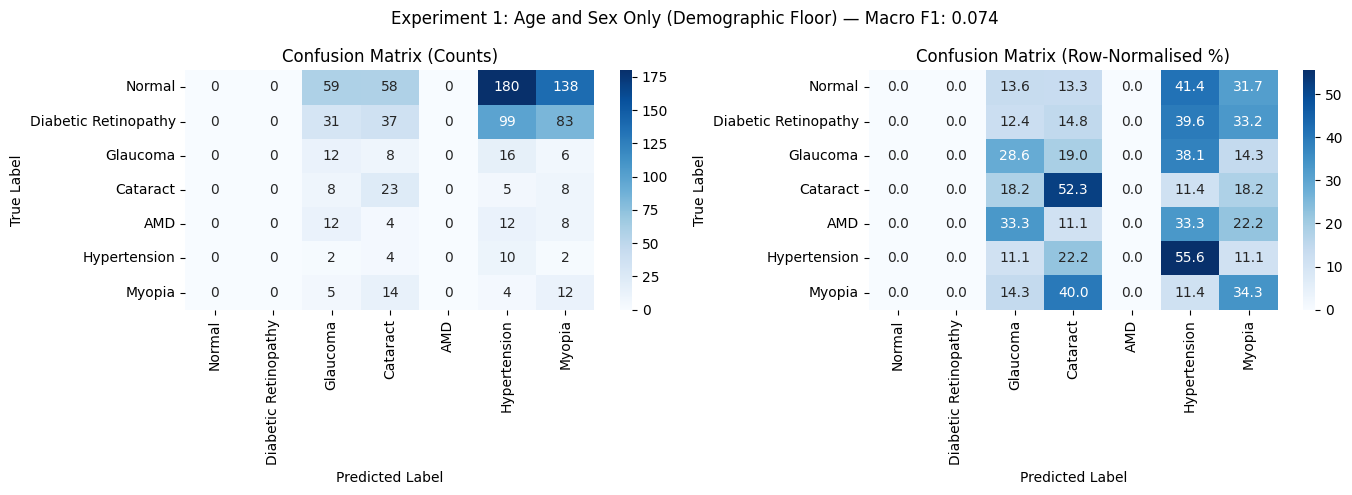

Figure saved: figLR1_age_sex.png



In [11]:
acc, f1 = run_logreg(
    train_meta, test_meta, train_true, test_true,
    name="Experiment 1: Age and Sex Only (Demographic Floor)",
    fig_name="figLR1_age_sex"
)
results['Age + Sex'] = {'accuracy': acc, 'macro_f1': f1}

### Cell 12 -- Experiment 2: Raw Concept Scores + Age + Sex

#### Primary logistic regression baseline using the 6 raw concept scores from the CBL combined with age and sex. Shows what a simple linear classifier can achieve directly on CBL outputs without fuzzification.

Experiment: Experiment 2: Raw Concept Scores + Age + Sex
-------------------------------------------------------
Accuracy : 0.4291 (42.91%)
Macro F1 : 0.3872

                      precision    recall  f1-score   support

              Normal       0.66      0.40      0.50       435
Diabetic Retinopathy       0.45      0.35      0.39       250
            Glaucoma       0.24      0.57      0.34        42
            Cataract       0.46      0.86      0.60        44
                 AMD       0.23      0.53      0.32        36
        Hypertension       0.08      0.39      0.14        18
              Myopia       0.35      0.51      0.41        35

            accuracy                           0.43       860
           macro avg       0.35      0.52      0.39       860
        weighted avg       0.53      0.43      0.45       860



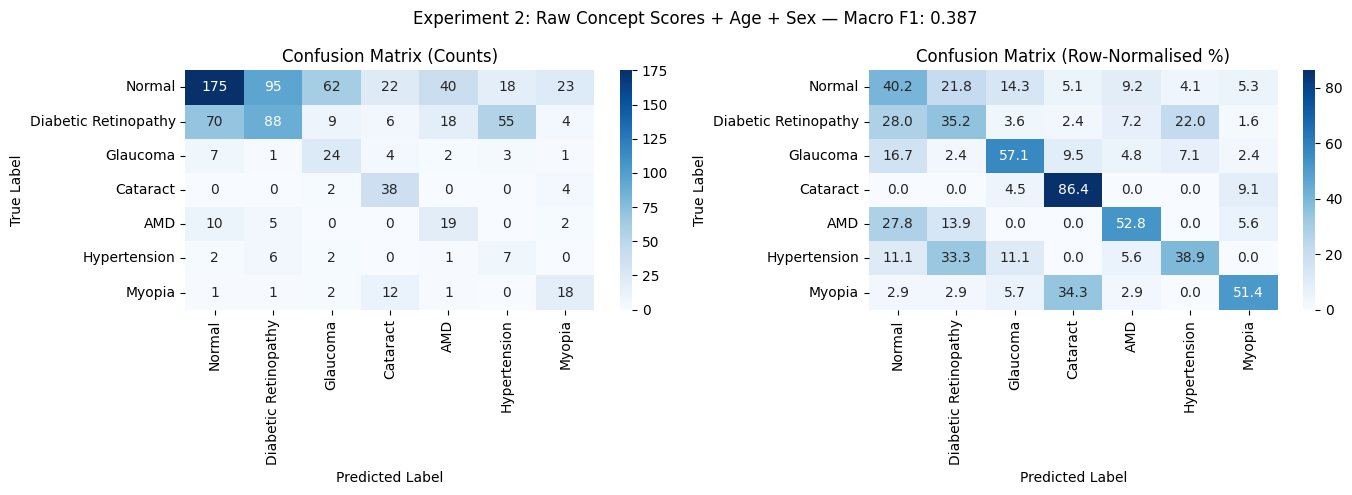

Figure saved: figLR2_raw_scores.png



In [12]:
acc, f1 = run_logreg(
    X_train_raw, X_test_raw, train_true, test_true,
    name="Experiment 2: Raw Concept Scores + Age + Sex",
    fig_name="figLR2_raw_scores"
)
results['Raw Scores + Age + Sex'] = {'accuracy': acc, 'macro_f1': f1}

### Cell 13 -- Experiment 3: Fuzzified Features

#### Logistic regression on the same 22 fuzzified features used by the FPT. Shows the contribution of fuzzification over raw scores and provides the most direct linear comparison against the FPT classifier.

Experiment: Experiment 3: Fuzzified Features (22 dimensions)
-------------------------------------------------------
Accuracy : 0.4593 (45.93%)
Macro F1 : 0.4328

                      precision    recall  f1-score   support

              Normal       0.68      0.44      0.53       435
Diabetic Retinopathy       0.46      0.35      0.40       250
            Glaucoma       0.26      0.57      0.36        42
            Cataract       0.55      0.93      0.69        44
                 AMD       0.25      0.53      0.34        36
        Hypertension       0.08      0.44      0.14        18
              Myopia       0.50      0.66      0.57        35

            accuracy                           0.46       860
           macro avg       0.40      0.56      0.43       860
        weighted avg       0.55      0.46      0.48       860



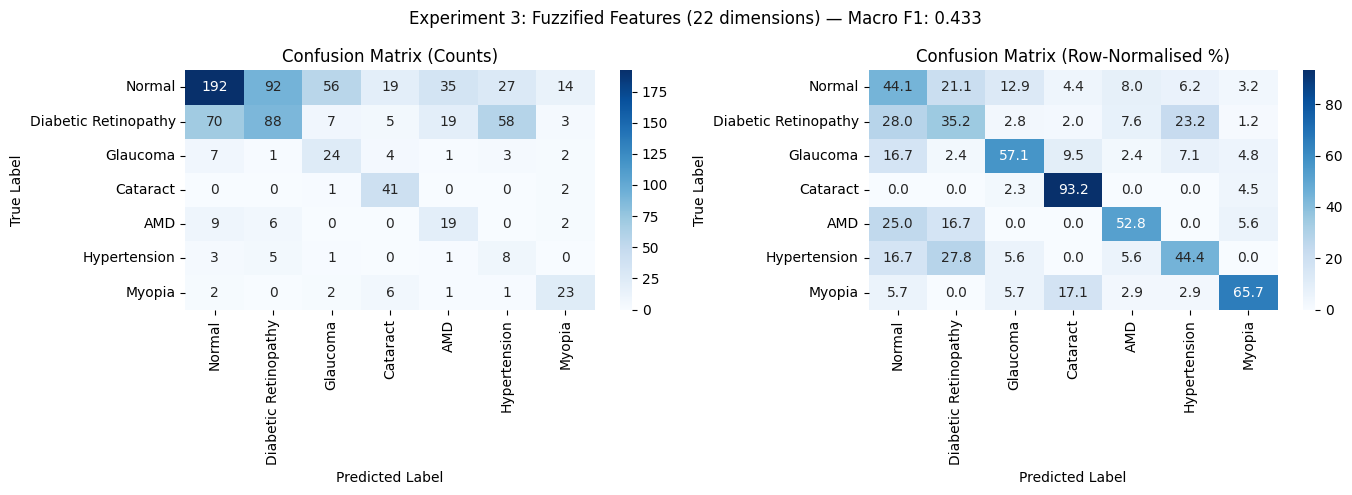

Figure saved: figLR3_fuzzified.png



In [13]:
acc, f1 = run_logreg(
    X_train_np, X_test_np, train_true, test_true,
    name="Experiment 3: Fuzzified Features (22 dimensions)",
    fig_name="figLR3_fuzzified"
)
results['Fuzzified Features'] = {'accuracy': acc, 'macro_f1': f1}

### Cell 14 -- Decision Tree Experiment 1: Raw Features

#### White-box rival to the FPT trained on raw concept scores + age + sex. Hyperparameters tuned via GridSearchCV with 3-fold cross-validation optimising Macro F1.

In [14]:
# Decision Tree on raw features
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

dt_raw = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt, cv=3, scoring='f1_macro', n_jobs=-1, verbose=0
)
dt_raw.fit(X_train_raw, train_true)
best_dt_raw = dt_raw.best_estimator_

preds_dt_raw = best_dt_raw.predict(X_test_raw)
acc_dt_raw   = accuracy_score(test_true, preds_dt_raw)
f1_dt_raw  = f1_score(test_true, preds_dt_raw, average='macro', zero_division=0)

print("Decision Tree — Raw Features (concept scores + age + sex)")
print(f"Best params: {dt_raw.best_params_}")
print(f"Accuracy : {acc_dt_raw:.4f} ({acc_dt_raw*100:.2f}%)")
print(f"Macro F1 : {f1_dt_raw:.4f}")
print()
print(classification_report(test_true, preds_dt_raw, target_names=disease_names, zero_division=0))

results['Decision Tree (Raw)'] = {'accuracy': acc_dt_raw, 'macro_f1': f1_dt_raw}

Decision Tree — Raw Features (concept scores + age + sex)
Best params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Accuracy : 0.4965 (49.65%)
Macro F1 : 0.4344

                      precision    recall  f1-score   support

              Normal       0.67      0.50      0.57       435
Diabetic Retinopathy       0.43      0.45      0.44       250
            Glaucoma       0.32      0.31      0.31        42
            Cataract       0.56      0.86      0.68        44
                 AMD       0.30      0.36      0.33        36
        Hypertension       0.11      0.39      0.17        18
              Myopia       0.42      0.74      0.54        35

            accuracy                           0.50       860
           macro avg       0.40      0.52      0.43       860
        weighted avg       0.54      0.50      0.51       860



### Cell 15 -- Decision Tree Experiment 2: Fuzzy Features

#### Decision Tree trained on the same 22 fuzzified features as the FPT with fine-tuned hyperparameters. The most direct white-box comparison against RETINEXPLAIN.

In [15]:
dt_fuzz = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt, cv=3, scoring='f1_macro', n_jobs=-1, verbose=0
)
dt_fuzz.fit(X_train_np, train_true)
best_dt_fuzz = dt_fuzz.best_estimator_

preds_dt_fuzz = best_dt_fuzz.predict(X_test_np)
acc_dt_fuzz   = accuracy_score(test_true, preds_dt_fuzz)
f1_dt_fuzz  = f1_score(test_true, preds_dt_fuzz, average='macro', zero_division=0)

print("Decision Tree — 22 Fuzzy Features")
print(f"Best params: {dt_fuzz.best_params_}")
print(f"Accuracy : {acc_dt_fuzz:.4f} ({acc_dt_fuzz*100:.2f}%)")
print(f"Macro F1 : {f1_dt_fuzz:.4f}")
print()
print(classification_report(test_true, preds_dt_fuzz, target_names=disease_names, zero_division=0))

results['Decision Tree (Fuzzy)'] = {'accuracy': acc_dt_fuzz, 'macro_f1': f1_dt_fuzz}

Decision Tree — 22 Fuzzy Features
Best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Accuracy : 0.4872 (48.72%)
Macro F1 : 0.3747

                      precision    recall  f1-score   support

              Normal       0.62      0.58      0.60       435
Diabetic Retinopathy       0.41      0.41      0.41       250
            Glaucoma       0.29      0.26      0.28        42
            Cataract       0.55      0.64      0.59        44
                 AMD       0.09      0.11      0.10        36
        Hypertension       0.15      0.22      0.18        18
              Myopia       0.42      0.54      0.47        35

            accuracy                           0.49       860
           macro avg       0.36      0.39      0.37       860
        weighted avg       0.50      0.49      0.49       860



### Cell 16 -- Random Forest Experiment 1: Raw Features

#### Non-interpretable ensemble baseline on raw concept scores + age + sex. Shows the accuracy ceiling without interpretability constraints.

In [16]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

rf_raw = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=3, scoring='f1_macro', n_jobs=-1, verbose=0
)
rf_raw.fit(X_train_raw, train_true)
best_rf_raw = rf_raw.best_estimator_

preds_rf_raw = best_rf_raw.predict(X_test_raw)
acc_rf_raw   = accuracy_score(test_true, preds_rf_raw)
f1_rf_raw  = f1_score(test_true, preds_rf_raw, average='macro', zero_division=0)

print("Random Forest — Raw Features")
print(f"Best params: {rf_raw.best_params_}")
print(f"Accuracy : {acc_rf_raw:.4f} ({acc_rf_raw*100:.2f}%)")
print(f"Macro F1 : {f1_rf_raw:.4f}")
print()
print(classification_report(test_true, preds_rf_raw, target_names=disease_names, zero_division=0))

results['Random Forest (Raw)'] = {'accuracy': acc_rf_raw, 'macro_f1': f1_rf_raw}

Random Forest — Raw Features
Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy : 0.5884 (58.84%)
Macro F1 : 0.5106

                      precision    recall  f1-score   support

              Normal       0.68      0.61      0.64       435
Diabetic Retinopathy       0.53      0.59      0.56       250
            Glaucoma       0.33      0.40      0.36        42
            Cataract       0.74      0.89      0.80        44
                 AMD       0.37      0.31      0.33        36
        Hypertension       0.28      0.28      0.28        18
              Myopia       0.55      0.66      0.60        35

            accuracy                           0.59       860
           macro avg       0.50      0.53      0.51       860
        weighted avg       0.60      0.59      0.59       860



### Cell 17 -- Random Forest Experiment 2: Fuzzy Features

#### Non-interpretable ensemble baseline on the same 22 fuzzified features as the FPT. 

In [17]:
rf_fuzz = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=3, scoring='f1_macro', n_jobs=-1, verbose=0
)
rf_fuzz.fit(X_train_np, train_true)
best_rf_fuzz = rf_fuzz.best_estimator_

preds_rf_fuzz = best_rf_fuzz.predict(X_test_np)
acc_rf_fuzz   = accuracy_score(test_true, preds_rf_fuzz)
f1_rf_fuzz  = f1_score(test_true, preds_rf_fuzz, average='macro', zero_division=0)

print("Random Forest — 22 Fuzzy Features")
print(f"Best params: {rf_fuzz.best_params_}")
print(f"Accuracy : {acc_rf_fuzz:.4f} ({acc_rf_fuzz*100:.2f}%)")
print(f"Macro F1 : {f1_rf_fuzz:.4f}")
print()
print(classification_report(test_true, preds_rf_fuzz, target_names=disease_names, zero_division=0))

results['Random Forest (Fuzzy)'] = {'accuracy': acc_rf_fuzz, 'macro_f1': f1_rf_fuzz}

Random Forest — 22 Fuzzy Features
Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy : 0.5756 (57.56%)
Macro F1 : 0.5003

                      precision    recall  f1-score   support

              Normal       0.66      0.59      0.62       435
Diabetic Retinopathy       0.52      0.58      0.55       250
            Glaucoma       0.29      0.38      0.33        42
            Cataract       0.76      0.86      0.81        44
                 AMD       0.34      0.28      0.31        36
        Hypertension       0.27      0.22      0.24        18
              Myopia       0.58      0.71      0.64        35

            accuracy                           0.58       860
           macro avg       0.49      0.52      0.50       860
        weighted avg       0.58      0.58      0.58       860



### Cell 18 -- Logistic Regression Feature Weights

#### Extracts and visualises the learned weights of the LR model from Experiment 2. Each weight shows how strongly a concept pushes toward or away from each disease class. Positive weight means the feature increases the probability of that class; negative means it decreases it. 

Logistic Regression Weights (Exp 2 — Raw Concept Scores + Age + Sex)
Positive = feature pushes toward this class | Negative = pushes away

                      haemorrhage  drusen  disc_pallor  vessel_tortuosity  red_spot  exudate    age    sex
Normal                     -2.265  -0.847       -0.176              0.058     2.901   -0.005 -0.004  0.011
Diabetic Retinopathy        0.298  -0.155       -0.129             -1.130     4.511    3.417 -0.018  0.136
Glaucoma                   -0.056  -1.686        6.685             -1.096     2.356   -0.047  0.020  0.142
Cataract                    0.832  -5.900       -2.181             -0.809    -6.626   -2.486  0.027 -0.187
AMD                        -2.483   6.867       -0.666              0.969     2.444    1.877  0.005  0.047
Hypertension                2.587  -1.422       -0.478              4.224     1.692   -0.950 -0.007  0.544
Myopia                      1.086   3.143       -3.056             -2.216    -7.278   -1.806 -0.023 -0.693



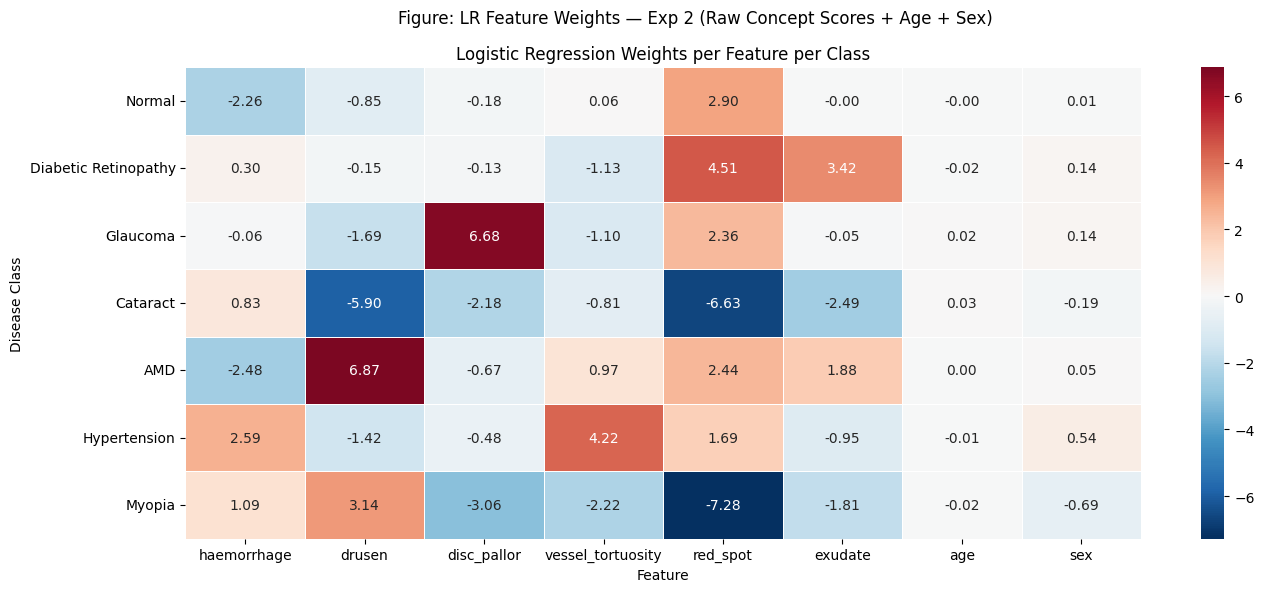

Figure saved: fig_lr_weights.png


In [18]:
clf_exp2 = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
clf_exp2.fit(X_train_raw, train_true)

feature_names_raw = concepts_list + ['age', 'sex']
coef_df = pd.DataFrame( clf_exp2.coef_, columns=feature_names_raw, index=disease_names)

print("Logistic Regression Weights (Exp 2 — Raw Concept Scores + Age + Sex)")
print("Positive = feature pushes toward this class | Negative = pushes away")
print()
print(coef_df.round(3).to_string())
print()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(coef_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
ax.set_title('Logistic Regression Weights per Feature per Class')
ax.set_xlabel('Feature'); ax.set_ylabel('Disease Class')
plt.suptitle('Figure: LR Feature Weights — Exp 2 (Raw Concept Scores + Age + Sex)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig_lr_weights.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig_lr_weights.png")

### Cell 19 -- Baseline Comparison Summary

#### Compares all baseline models by accuracy and Macro F1. Interpretable models are flagged separately. Bar charts show both metrics side by side and Macro F1 alone as the primary metric for imbalanced classification.

FULL BASELINE COMPARISON SUMMARY
  Model                                Accuracy  Macro F1  Interpretable
  -------------------------------------------------------------------
  Age + Sex                              0.0663    0.0743            Yes
  Raw Scores + Age + Sex                 0.4291    0.3872            Yes
  Fuzzified Features                     0.4593    0.4328            Yes
  Decision Tree (Raw)                    0.4965    0.4344            Yes
  Decision Tree (Fuzzy)                  0.4872    0.3747            Yes
  Random Forest (Raw)                    0.5884    0.5106             No
  Random Forest (Fuzzy)                  0.5756    0.5003             No



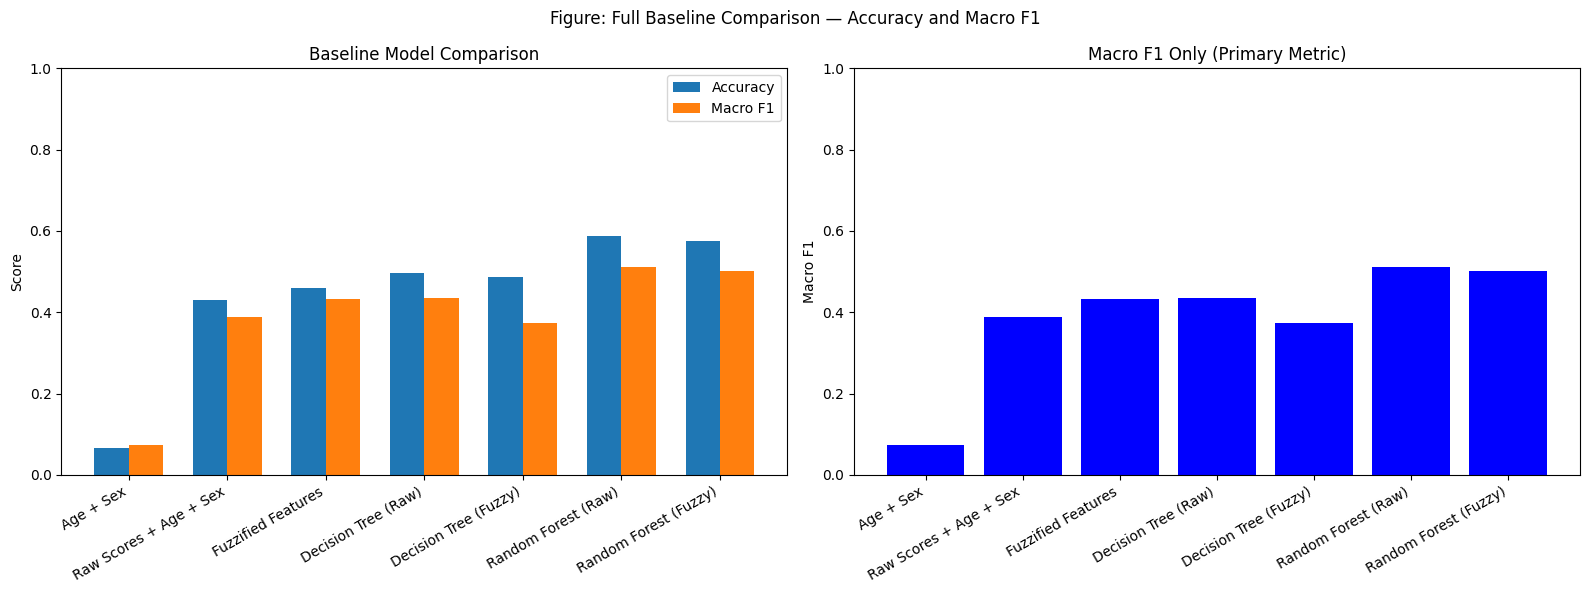

Figure saved: fig_baseline_comparison.png


In [19]:
print("=" * 65)
print("FULL BASELINE COMPARISON SUMMARY")
print("=" * 65)
print(f"  {'Model':<35}  {'Accuracy':>8}  {'Macro F1':>8}  {'Interpretable':>13}")
print("  " + "-" * 67)
for name, res in results.items():
    interp = 'Yes' if any(x in name for x in ['Age', 'Raw Scores', 'Fuzzified', 'Decision Tree']) else 'No'
    print(f"  {name:<35}  {res['accuracy']:>8.4f}  {res['macro_f1']:>8.4f}  {interp:>13}")
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
f1s   = [results[n]['macro_f1'] for n in names]

x = np.arange(len(names))
w = 0.35
axes[0].bar(x - w/2, accs, w, label='Accuracy')
axes[0].bar(x + w/2, f1s,  w, label='Macro F1')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30, ha='right')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Score')
axes[0].set_title('Baseline Model Comparison')
axes[0].legend()

axes[1].bar(x, f1s, color='blue')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=30, ha='right')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Macro F1 Only (Primary Metric)')

plt.suptitle('Figure: Full Baseline Comparison — Accuracy and Macro F1', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig_baseline_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig_baseline_comparison.png")

### Cell 20 -- Baseline Results Summary

#### Summary table of all baseline experiments showing accuracy, Macro F1 and interpretability flag for each model configuration.

In [20]:
print("=" * 65)
print("Baseline Results Summary")
print("=" * 65)
print(f"  {'Model':<35}  {'Accuracy':>8}  {'Macro F1':>8}  {'Interpretable':>13}")
print("  " + "-" * 67)
for name, res in results.items():
    interp = 'Yes' if any(x in name for x in ['Age', 'Raw Scores', 'Fuzzified', 'Decision Tree']) else 'No'
    print(f"  {name:<35}  {res['accuracy']:>8.4f}  {res['macro_f1']:>8.4f}  {interp:>13}")

Baseline Results Summary
  Model                                Accuracy  Macro F1  Interpretable
  -------------------------------------------------------------------
  Age + Sex                              0.0663    0.0743            Yes
  Raw Scores + Age + Sex                 0.4291    0.3872            Yes
  Fuzzified Features                     0.4593    0.4328            Yes
  Decision Tree (Raw)                    0.4965    0.4344            Yes
  Decision Tree (Fuzzy)                  0.4872    0.3747            Yes
  Random Forest (Raw)                    0.5884    0.5106             No
  Random Forest (Fuzzy)                  0.5756    0.5003             No
